# Seasonality forecasting using Exponential Smoothing
#This script performs Time Series Analysis on online retail data. This dataset is publically available with no sensitive information. The data is aggregated to Median per hour, RIMA applied and validated using Root Median Squared Error (RMSE) and Augmented Dicky Fuller. Data is split 70/30 for test/training.

Author: Jason Jacskon-Allen Date: 30_04_2026

<a id="table-of-contents"></a>
## Table of Contents
1. [Install Libraries & Load Data](#Install-Libraries-&-Load-Data)
2. [Data Preparation](#Data-Preparation)
3. [Time Series](#Create-Time-Series)
4. [Dickey-Fuller Test](#Dickey-Fuller-Test-&-ARIMA-Model-creation)
5. [ARIMA Model](#ARIMA-Model)
6. [Training & Forecasting](#Training-and-Forecasting)

## Install Libraries & Load Data

In [3]:
# Import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [5]:
# Load data from Excel file
df = pd.read_excel(r"C:\Users\jason.jackson-allen\OneDrive - Wiltshire Council\Desktop\BPP\Data Science Professional Practice\online_retail_II.xlsx")
print(df.head(3))

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  


## Data Preparation

In [141]:
# Remove cancellations

df['Invoice'] = df['Invoice'].astype('string')
df = df[~df['Invoice'].str.startswith('C', na=False)]

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [142]:
#Set column type to date/time and aggregate per day
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Quantity'] = df['Quantity'] * df['Price']

In [143]:
# Aggregate daily units sold
daily_quantity = (
    df
    .set_index('InvoiceDate')
    .resample('D')['Quantity']
    .sum()
)

# Average daily sales
average_daily_quantity = daily_quantity.mean()

print(f"The Average Daily quantity are: {average_daily_quantity:.2f}")

The Average Daily quantity are: 5651400.01


## Create Time Series

In [35]:
#Create Time Stamp and Target value for Prophet
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['Quantity']
      .sum()
      .reset_index()
)

daily_sales.columns = ['date', 'Quantity']

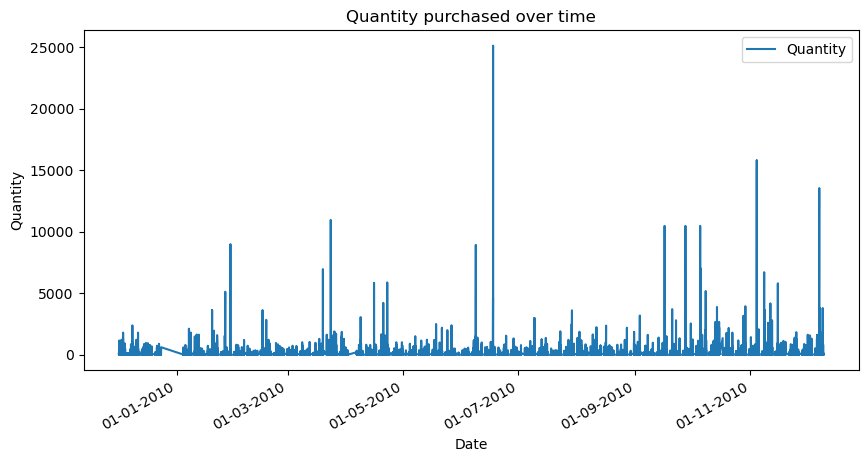

In [36]:
# Create the figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot series
ax.plot(df['InvoiceDate'], df['Quantity'], label='Quantity')


# Format dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
fig.autofmt_xdate()

# Labels
plt.title('Quantity purchased over time')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.legend()
plt.show()

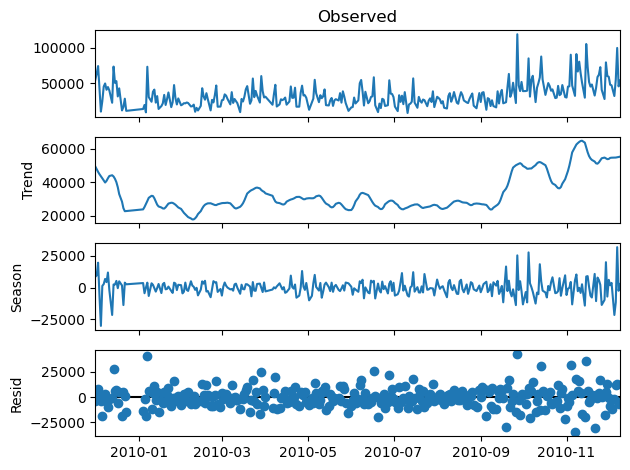

In [37]:
#Season Decomposition strip data of core parts
stl= STL(daily_sales.set_index('date'), period=7)
res = stl.fit()
res.plot()
plt.show()


## Split the data

In [38]:
#Create a training and test split 70/30
train = daily_sales.iloc[:-30]
test = daily_sales.iloc[-30:]

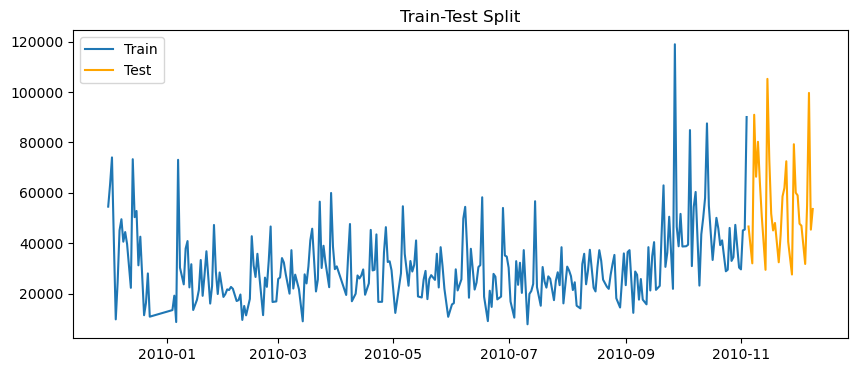

In [39]:
#Create a training and test split 70/30
plt.figure(figsize=(10,4))
plt.plot(train['date'], train['Quantity'],
label = 'Train')
plt.plot(test['date'], test['Quantity'],
label = 'Test', color='orange')
plt.title('Train-Test Split')
plt.legend()
plt.show()

## Modelling Exponential Smoothing (ETS)

## Training and Forecasting

In [41]:
# Ensure Quantity is numeric
train['Quantity'] = pd.to_numeric(train['Quantity'], errors='coerce')

# Drop missing values created during conversion
train = train.dropna(subset=['Quantity'])

# (Optional but recommended) ensure float dtype
train['Quantity'] = train['Quantity'].astype(float)

In [144]:
#Fit the model 


model = ExponentialSmoothing(
    train['Quantity'],
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=7
).fit()


C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [145]:
forecast = model.forecast(30)
print(forecast.head())

277    42727.485492
278    52944.555016
279    49803.038962
280    47528.715714
281    46368.410905
dtype: float64


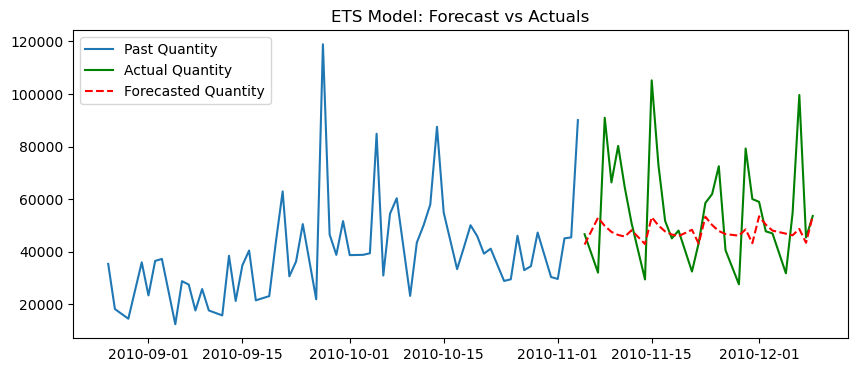

In [146]:
#Display the forecast

plt.figure(figsize=(10,4))
plt.plot(train['date'].iloc[-60:], train['Quantity'].iloc[-60:],
label = 'Past Quantity')
plt.plot(test['date'], test['Quantity'],
label = 'Actual Quantity', color='green')
plt.plot(test['date'], forecast,
label = 'Forecasted Quantity', color='red', linestyle='--')
plt.title('ETS Model: Forecast vs Actuals')
plt.legend()
plt.show()


In [137]:
#Mean absolute squared error
mae=mean_absolute_error(test['Quantity'], forecast)

print(f"The Mean Absolute Error is:{mae:.2f}")


The Mean Absolute Error is:12940.21


In [138]:
error_rate = (mae / average_daily_quantity)*100
accuracy_rate = 100 - error_rate

In [139]:
#Print a summary
print("-" *30)
print("Retail Stock Forecasting")
print("-" *30)
print(f"Average Daily Demand: {average_daily_quantity:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f} units")
print(f"Model Error Rate:{error_rate:,.2f}%")
print(f"Model Accuracy:{accuracy_rate:,.2f}%")
print("-" *30)

------------------------------
Retail Stock Forecasting
------------------------------
Average Daily Demand: 27,555.86
Mean Absolute Error (MAE): 12,940.21 units
Model Error Rate:46.96%
Model Accuracy:53.04%
------------------------------


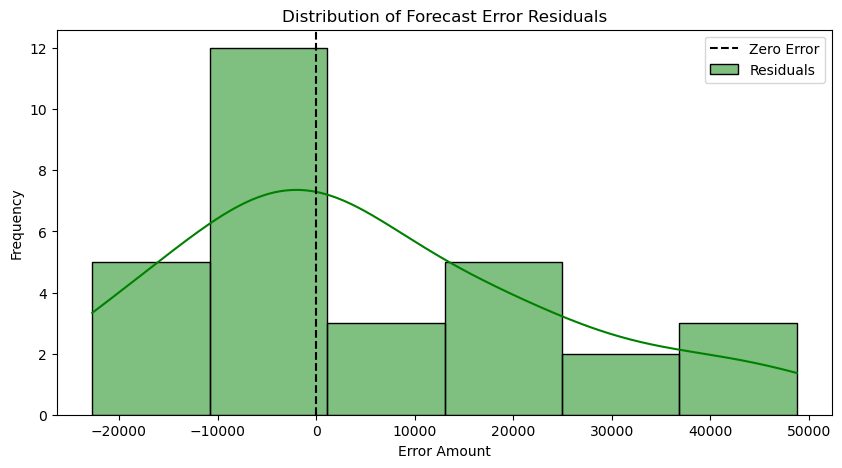

In [28]:
# Calculate residuals
test_residuals = test['Quantity'] - forecast

plt.figure(figsize=(10, 5))

sns.histplot(
    test_residuals,
    kde=True,
    color='green',
    label='Residuals'
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    label='Zero Error'
)

plt.title('Distribution of Forecast Error Residuals')
plt.xlabel('Error Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()